Saved executed Colab notebook imported on 2026-09-04. Existing outputs are the original run, not a new training run. Its test accuracy (0.6842062393), validation macro-F1 (0.7277523386), epoch 3 checkpoint and class-weight power 0.5 match models/emotion/metadata.json. The deployed model is DistilBERT on TweetEval sentiment. TweetEval differs from the PDF dataset: it supplies a genuine neutral class. Happy/neutral/sad mean positive/neutral/negative. Dataset acceptance is a TA decision; no 90% result is claimed.

# 2. Customer emotion classifier: happy, neutral, sad

**Training notebook — run in Google Colab with a GPU. No full training results are supplied in advance.**

We interpret the instructor's three names as customer sentiment:

| Output | Training meaning | Example |
|---|---|---|
| happy | positive / satisfied | “I love it. Thank you!” |
| neutral | factual / no clear positive or negative sentiment | “Where can I find my invoice?” |
| sad | negative / dissatisfied, including frustration | “This is disappointing. It still hasn't arrived.” |

This is a **three-class sentiment classifier**, not a clinical or literal sadness detector. `sad` is a display name for negative sentiment. The original `dair-ai/emotion` dataset has no neutral class, so it cannot supply these three labels by simply renaming its six emotions. We use the **sentiment subset of TweetEval** because it contains real negative, neutral, and positive labels. Do not map surprise to neutral.

The instructor confirmed three class names, but did not define their semantics; this is our documented interpretation. If literal happiness/sadness was intended, the dataset must change.

[Dataset and label definitions](https://huggingface.co/datasets/cardiffnlp/tweet_eval) · [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) · [Transformer classification](https://huggingface.co/docs/transformers/tasks/sequence_classification)

## Before running

1. Upload this notebook to Colab.
2. Select **Runtime → Change runtime type → T4 GPU** (or another available GPU).
3. Run the installation cell first. If Colab asks for a session restart, restart and continue from the configuration cell.
4. Use **Run all** in a fresh runtime. Training uses no API key.
5. Download the generated `emotion_classifier_export.zip` **and the executed notebook** when finished. Upload both back for local integration.

A GPU is recommended for training; the exported model runs on local CPU. Free Colab resources and availability vary. If the runtime disconnects, temporary storage can be lost; the optional Drive setting below stores best-epoch checkpoints persistently. It does not implement automatic optimizer-state resumption.


In [4]:
# Install dependencies for the Python 3.13 Colab runtime.
import sys
import subprocess

print("Python:", sys.version)

packages = [
    "transformers==4.57.6",
    "tokenizers==0.22.2",
    "safetensors>=0.4.1,<1",
    "numpy>=1.26,<3",
    "pandas>=2.2.3,<3.1",
    "pyarrow==21.0.0",
    "scikit-learn==1.6.1",
    "matplotlib>=3.9,<3.11",
    "certifi",
]

# Keep Colab's existing GPU-enabled PyTorch installation.
# Show installation output so any failure is visible.
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--upgrade", "--prefer-binary",
    *packages,
])

print(
    "\nInstallation completed.\n"
    "Select Runtime → Restart session, "
    "then continue from the configuration cell."
)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

Installation completed.
Select Runtime → Restart session, then continue from the configuration cell.


## Configuration and reproducibility

Start with the settings below. **An epoch is one pass through the training data.** Batch size controls how many texts are processed together; maximum length limits the number of tokens per message. Learning rate controls the size of each update. We select the best of three epochs using validation macro-F1, rather than assume the final epoch is best.

`SAVE_TO_DRIVE=True` asks you to mount your own Google Drive. Otherwise files stay in Colab's temporary storage until downloaded. Each run receives its own folder, so a rerun does not overwrite another run's model.


In [13]:
from pathlib import Path
from datetime import datetime, timezone
import os
SAVE_TO_DRIVE = False
SEED = 42
EPOCHS = 3
BATCH_SIZE = 32
MAX_LENGTH = 128
LEARNING_RATE = 2e-5
CLASS_WEIGHT_POWER = 0.5

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = Path('/content/drive/MyDrive/ITI_ChatBot_Emotion')
else:
    PROJECT = Path('/content/ITI_ChatBot_Emotion')
RUN = PROJECT / 'runs' / datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S-%f')
REPORTS = RUN / 'reports'
REPORTS.mkdir(parents=True, exist_ok=True)
os.environ['HF_HOME'] = '/content/iti_huggingface_cache'
os.environ['MPLCONFIGDIR'] = '/content/iti_matplotlib_cache'
print('This run:', RUN)


This run: /content/ITI_ChatBot_Emotion/runs/20260903-085248-280894


In [14]:
from pathlib import Path
import copy
import hashlib
import json
import random
import re
import shutil
import ssl
import time
import unicodedata
import urllib.request
import warnings
from importlib.metadata import version
from datetime import datetime, timezone

import certifi
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

DATASET_ID = 'cardiffnlp/tweet_eval'
DATASET_REVISION = 'b3a375baf0f409c77e6bc7aa35102b7b3534f8be'
MODEL_ID = 'distilbert/distilbert-base-uncased'
MODEL_REVISION = '12040accade4e8a0f71eabdb258fecc2e7e948be'
ID2LABEL = {0: 'sad', 1: 'neutral', 2: 'happy'}
LABEL2ID = {name: number for number, name in ID2LABEL.items()}
SOURCE_LABELS = ['negative', 'neutral', 'positive']


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



seed_everything(SEED)
assert torch.cuda.is_available(), 'GPU not detected. Select a GPU runtime before training.'
DEVICE = torch.device('cuda')
print('GPU:', torch.cuda.get_device_name(0))
print('Class mapping:', ID2LABEL)
print('Source labels:', SOURCE_LABELS)


GPU: Tesla T4
Class mapping: {0: 'sad', 1: 'neutral', 2: 'happy'}
Source labels: ['negative', 'neutral', 'positive']


## Data preparation

We download the official train/validation/test splits at a fixed revision and verify their label definitions. Keep punctuation, emojis, and words such as “not”: they express sentiment. Normalize URLs and user handles consistently at training and inference.

Within each split, remove blank text, texts with conflicting labels, and exact duplicates after normalization. Remove validation/test texts already seen in an earlier split, without changing training based on test labels. Near duplicates remain possible. Therefore report our score on the **cleaned subset**, not as an official TweetEval benchmark score.

Only training data is used to calculate class weights. Validation chooses checkpoints and the review threshold. Test data measures the finished model.


,split,original,retained,conflicting_rows,within_split_duplicate_rows,earlier_split_overlap_rows
0,train,45615,45582,6,27,0
1,validation,2000,2000,0,0,0
2,test,12284,12277,7,0,0


,train,validation,test
sad,7091,312,3968
neutral,20653,869,5934
happy,17838,819,2375


,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


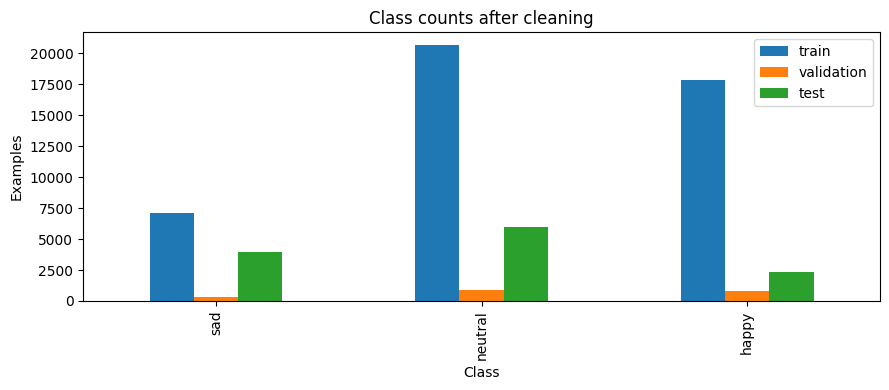

In [15]:
def clean_emotion_text(text):
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'https?://\S+|www\.\S+', 'http', text)
    text = re.sub(r'(?<!\w)@[\w]+', '@user', text)
    return ' '.join(text.split())


def download_emotion_data(destination):
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)
    manifest = {'dataset': DATASET_ID, 'subset': 'sentiment', 'revision': DATASET_REVISION, 'files': {}}
    manifest_path = destination / 'manifest.json'
    previous = json.loads(manifest_path.read_text()) if manifest_path.exists() else None
    frames = {}
    context = ssl.create_default_context(cafile=certifi.where())
    for split in ['train', 'validation', 'test']:
        path = destination / f'{split}.parquet'
        url = f'https://huggingface.co/datasets/{DATASET_ID}/resolve/{DATASET_REVISION}/sentiment/{split}-00000-of-00001.parquet'
        if not path.exists():
            temporary = path.with_suffix('.partial')
            with urllib.request.urlopen(url, context=context, timeout=120) as source, temporary.open('wb') as target:
                shutil.copyfileobj(source, target)
            temporary.replace(path)
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        if previous and previous['files'][split]['sha256'] != digest:
            raise ValueError(f'{split} data differs from its recorded checksum.')
        table = pq.read_table(path)
        schema_info = json.loads(table.schema.metadata[b'huggingface'])
        assert schema_info['info']['features']['label']['names'] == SOURCE_LABELS
        frames[split] = table.to_pandas()
        assert set(frames[split].label) == {0, 1, 2}
        manifest['files'][split] = {'sha256': digest, 'url': url, 'rows': len(frames[split])}
    manifest_path.write_text(json.dumps(manifest, indent=2) + '\n')
    return frames, manifest


def prepare_emotion_splits(raw):
    cleaned, audit, seen = {}, [], set()
    for split in ['train', 'validation', 'test']:
        frame = raw[split].dropna(subset=['text', 'label']).copy()
        frame['text'] = frame.text.map(clean_emotion_text)
        frame = frame[frame.text.str.len() > 0].copy()
        frame['key'] = frame.text.str.casefold()
        conflicts = set(frame.groupby('key').label.nunique().loc[lambda x: x > 1].index)
        conflict_rows = int(frame.key.isin(conflicts).sum())
        frame = frame[~frame.key.isin(conflicts)]
        duplicate_rows = int(frame.duplicated('key').sum())
        frame = frame.drop_duplicates('key')
        overlap_rows = int(frame.key.isin(seen).sum())
        frame = frame[~frame.key.isin(seen)].copy()
        seen.update(frame.key)
        frame = frame[['text', 'label']].reset_index(drop=True)
        assert set(frame.label) == {0, 1, 2}
        cleaned[split] = frame
        audit.append({'split': split, 'original': len(raw[split]), 'retained': len(frame),
                      'conflicting_rows': conflict_rows, 'within_split_duplicate_rows': duplicate_rows,
                      'earlier_split_overlap_rows': overlap_rows})
    return cleaned, pd.DataFrame(audit)



raw, dataset_manifest = download_emotion_data(PROJECT / 'data')
splits, audit = prepare_emotion_splits(raw)
audit.to_csv(REPORTS / 'data_audit.csv', index=False)
display(audit)
counts = pd.DataFrame({name: frame.label.value_counts().reindex([0,1,2]) for name, frame in splits.items()})
counts.index = [ID2LABEL[i] for i in counts.index]
counts.to_csv(REPORTS / 'class_counts.csv')
display(counts)
display(splits['train'].head())
import matplotlib.pyplot as plt
ax = counts.plot.bar(figsize=(9,4), title='Class counts after cleaning')
ax.set_xlabel('Class')
ax.set_ylabel('Examples')
plt.tight_layout()
plt.savefig(REPORTS / 'class_counts.png', dpi=150)
plt.show()


## Tokenization and the pretrained model

A tokenizer converts text into token IDs and an attention mask. It is different from TF-IDF: it prepares the input expected by the Transformer. We start from **base DistilBERT**, not a sentiment model already fine-tuned on this test set. The language representations are pretrained; its three-class classification head is newly initialized and must be trained.

The warning that classification-head weights are newly initialized is expected. Dynamic padding pads each batch only as far as its longest message. Messages exceeding MAX_LENGTH are truncated; we report how frequently that occurs in training and validation.


In [16]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, revision=MODEL_REVISION)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, revision=MODEL_REVISION, use_safetensors=True,
    num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID)
for split in ['train','validation']:
    lengths = tokenizer(splits[split].text.tolist(), truncation=False, return_length=True)['length']
    print(split, 'fraction longer than MAX_LENGTH:', float(np.mean(np.array(lengths)>MAX_LENGTH)))
print(tokenizer('I am not happy with this order.'))


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


train fraction longer than MAX_LENGTH: 0.0
validation fraction longer than MAX_LENGTH: 0.0
{'input_ids': [101, 1045, 2572, 2025, 3407, 2007, 2023, 2344, 1012, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


## Batches and evaluation

The following functions create shuffled training batches and unshuffled evaluation batches. During evaluation, `model.eval()` disables dropout and `torch.inference_mode()` avoids gradient calculations.

Accuracy measures the overall fraction correct. Macro-F1 gives equal importance to all three classes, so predicting neutral for most messages cannot hide poor sad/happy performance. The majority-class baseline below helps put the final accuracy in context; it is not the required neural model.


In [17]:
class EmotionDataset(Dataset):
    def __init__(self, frame):
        self.texts = frame.text.tolist()
        self.labels = frame.label.tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        return {'text': self.texts[index], 'label': self.labels[index]}


class EmotionCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer, self.max_length = tokenizer, max_length

    def __call__(self, examples):
        batch = self.tokenizer([example['text'] for example in examples], padding=True,
                               truncation=True, max_length=self.max_length, return_tensors='pt')
        batch['labels'] = torch.tensor([example['label'] for example in examples], dtype=torch.long)
        return batch


def make_loader(frame, tokenizer, batch_size, max_length, shuffle=False, seed=42):
    return DataLoader(EmotionDataset(frame), batch_size=batch_size, shuffle=shuffle,
                      collate_fn=EmotionCollator(tokenizer, max_length), num_workers=0,
                      generator=torch.Generator().manual_seed(seed))


@torch.inference_mode()
def predict_text_probabilities(model, tokenizer, texts, device, batch_size=32, max_length=128):
    model.eval()
    probabilities = []
    for start in range(0, len(texts), batch_size):
        encoded = tokenizer([clean_emotion_text(t) for t in texts[start:start + batch_size]],
                            padding=True, truncation=True, max_length=max_length, return_tensors='pt')
        inputs = {key: tensor.to(device) for key, tensor in encoded.items()}
        probabilities.extend(model(**inputs).logits.softmax(dim=-1).cpu().tolist())
    return np.asarray(probabilities)


@torch.inference_mode()
def evaluate_emotion(model, loader, device):
    model.eval()
    truths, probabilities = [], []
    for batch in loader:
        labels = batch.pop('labels')
        inputs = {key: tensor.to(device) for key, tensor in batch.items()}
        logits = model(**inputs).logits
        truths.extend(labels.tolist())
        probabilities.extend(logits.softmax(dim=-1).cpu().tolist())
    truth, probabilities = np.asarray(truths), np.asarray(probabilities)
    predicted = probabilities.argmax(axis=1)
    return {'accuracy': float(accuracy_score(truth, predicted)),
            'macro_f1': float(f1_score(truth, predicted, average='macro', labels=[0,1,2], zero_division=0))}, truth, probabilities



majority = int(splits['train'].label.mode().iloc[0])
majority_pred = np.full(len(splits['validation']), majority)
majority_baseline = {'predicted_class':ID2LABEL[majority],
    'validation_accuracy':float(accuracy_score(splits['validation'].label, majority_pred)),
    'validation_macro_f1':float(f1_score(splits['validation'].label, majority_pred, average='macro', labels=[0,1,2], zero_division=0))}
print('Majority baseline:', majority_baseline)
(REPORTS/'majority_baseline.json').write_text(json.dumps(majority_baseline,indent=2))


Majority baseline: {'predicted_class': 'neutral', 'validation_accuracy': 0.4345, 'validation_macro_f1': 0.20192866271639365}


113

## Fine-tuning

We use class-weighted cross-entropy to give less frequent classes adequate influence. The class weights are computed only from training counts. AdamW updates the parameters; a warmup and decay schedule adjusts the learning rate. Gradient clipping limits unstable updates. GPU mixed precision reduces memory usage.

The loop saves a checkpoint whenever validation macro-F1 improves. The test split is never passed to this training function. A training loss is an optimization signal, not an accuracy score. We do not promise language-detection-level accuracy for this harder, subjective task.


Class weights: {'sad': 1.4638019800186157, 'neutral': 0.8577179312705994, 'happy': 0.9229177236557007}
Epoch 1/3, batch 100/1425, mean weighted loss 1.0808
Epoch 1/3, batch 200/1425, mean weighted loss 1.0302
Epoch 1/3, batch 300/1425, mean weighted loss 0.9505
Epoch 1/3, batch 400/1425, mean weighted loss 0.9011
Epoch 1/3, batch 500/1425, mean weighted loss 0.8665
Epoch 1/3, batch 600/1425, mean weighted loss 0.8365
Epoch 1/3, batch 700/1425, mean weighted loss 0.8173
Epoch 1/3, batch 800/1425, mean weighted loss 0.7974
Epoch 1/3, batch 900/1425, mean weighted loss 0.7861
Epoch 1/3, batch 1000/1425, mean weighted loss 0.7751
Epoch 1/3, batch 1100/1425, mean weighted loss 0.7648
Epoch 1/3, batch 1200/1425, mean weighted loss 0.7563
Epoch 1/3, batch 1300/1425, mean weighted loss 0.7477
Epoch 1/3, batch 1400/1425, mean weighted loss 0.7399
Epoch 1/3, batch 1425/1425, mean weighted loss 0.7386
Validation: {'epoch': 1, 'mean_weighted_training_loss': 0.7385618371712535, 'seconds': 93.038182

,epoch,mean_weighted_training_loss,seconds,accuracy,macro_f1
0,1,0.738562,93.038182,0.7135,0.700962
1,2,0.544297,93.751033,0.7340,0.721267
2,3,0.431636,94.060186,0.7410,0.727752


Selected checkpoint: {'best_epoch': 3, 'best_validation_macro_f1': 0.7277523386182304, 'class_weight_power': 0.5, 'class_weights': [1.4638019800186157, 0.8577179312705994, 0.9229177236557007]}


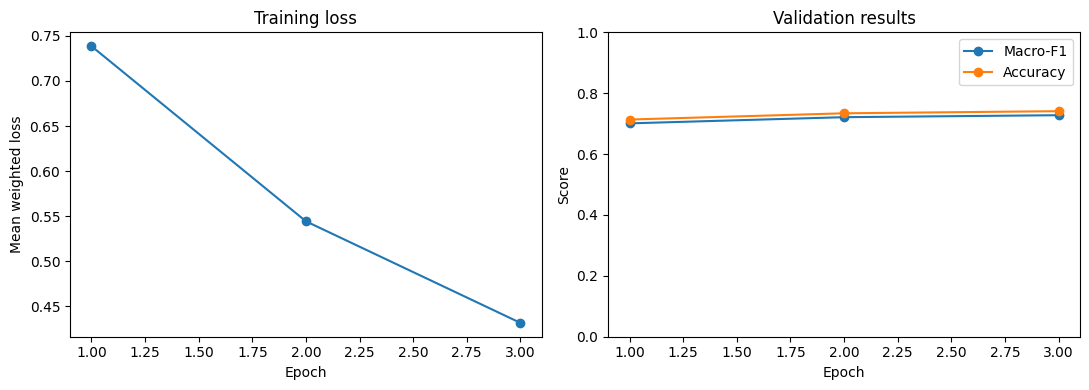

In [18]:
import gc

CLASS_WEIGHT_POWER = 0.5


def train_emotion(
    model,
    tokenizer,
    splits,
    output_dir,
    device,
    epochs=3,
    batch_size=32,
    max_length=128,
    learning_rate=2e-5,
    seed=42,
    class_weight_power=0.5,
):
    """Select the best validation macro-F1 checkpoint; never use test data."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    best_dir = output_dir / "best_model"

    train_loader = make_loader(
        splits["train"],
        tokenizer,
        batch_size,
        max_length,
        shuffle=True,
        seed=seed,
    )
    val_loader = make_loader(
        splits["validation"],
        tokenizer,
        batch_size,
        max_length,
    )

    # Compute gentler class weights using training data only.
    counts = (
        splits["train"].label.value_counts()
        .reindex([0, 1, 2], fill_value=0)
        .to_numpy()
    )

    if (counts == 0).any():
        raise ValueError("Training data must contain all three classes.")

    base_weights = len(splits["train"]) / (3 * counts)
    weights = torch.tensor(
        base_weights ** class_weight_power,
        dtype=torch.float32,
        device=device,
    )

    print("Class weights:", dict(zip(["sad", "neutral", "happy"],
                                         weights.cpu().tolist())))

    model.to(device)
    criterion = torch.nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.01,
    )

    total_steps = epochs * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps,
    )

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    history = []
    best_f1 = -1.0
    best_epoch = None

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = 0.0
        batches = 0
        started = time.perf_counter()

        for batch_index, batch in enumerate(train_loader, start=1):
            labels = batch.pop("labels").to(device)
            inputs = {
                key: value.to(device)
                for key, value in batch.items()
            }

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp,
            ):
                logits = model(**inputs).logits
                loss = criterion(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    "Non-finite training loss: stop and investigate."
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            previous_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()

            # Advance the scheduler only when the optimizer step succeeded.
            if scaler.get_scale() >= previous_scale:
                scheduler.step()

            loss_sum += loss.item()
            batches += 1

            if batch_index % 100 == 0 or batch_index == len(train_loader):
                print(
                    f"Epoch {epoch}/{epochs}, "
                    f"batch {batch_index}/{len(train_loader)}, "
                    f"mean weighted loss {loss_sum / batches:.4f}",
                    flush=True,
                )

        validation, _, _ = evaluate_emotion(
            model, val_loader, device
        )

        record = {
            "epoch": epoch,
            "mean_weighted_training_loss": loss_sum / batches,
            "seconds": time.perf_counter() - started,
            **validation,
        }
        history.append(record)
        print("Validation:", record, flush=True)

        if validation["macro_f1"] > best_f1:
            best_f1 = validation["macro_f1"]
            best_epoch = epoch
            model.save_pretrained(best_dir, safe_serialization=True)
            tokenizer.save_pretrained(best_dir)

        (output_dir / "training_history.json").write_text(
            json.dumps(history, indent=2) + "\n"
        )

    selection = {
        "best_epoch": best_epoch,
        "best_validation_macro_f1": best_f1,
        "class_weight_power": class_weight_power,
        "class_weights": weights.cpu().tolist(),
    }

    return best_dir, history, selection


# Keep this experiment separate from the original run.
EXPERIMENT_RUN = RUN / (
    "gentler_weights_"
    + datetime.now(timezone.utc).strftime("%Y%m%d-%H%M%S-%f")
)
REPORTS = EXPERIMENT_RUN / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

best_directory, history, selection = train_emotion(
    model,
    tokenizer,
    splits,
    EXPERIMENT_RUN,
    DEVICE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    learning_rate=LEARNING_RATE,
    seed=SEED,
    class_weight_power=CLASS_WEIGHT_POWER,
)

display(pd.DataFrame(history))
print("Selected checkpoint:", selection)

shutil.copy2(
    EXPERIMENT_RUN / "training_history.json",
    REPORTS / "training_history.json",
)

# Make later notebook cells use this experiment's folder.
RUN = EXPERIMENT_RUN

# Release the last-epoch model, then load the best checkpoint.
del model
gc.collect()
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

best_model = AutoModelForSequenceClassification.from_pretrained(
    best_directory,
    use_safetensors=True,
).to(DEVICE)
best_model.eval()

# Plot this experiment's learning curves.
history_frame = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    history_frame["epoch"],
    history_frame["mean_weighted_training_loss"],
    marker="o",
)
axes[0].set(
    title="Training loss",
    xlabel="Epoch",
    ylabel="Mean weighted loss",
)

axes[1].plot(
    history_frame["epoch"],
    history_frame["macro_f1"],
    marker="o",
    label="Macro-F1",
)
axes[1].plot(
    history_frame["epoch"],
    history_frame["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1].set(
    title="Validation results",
    xlabel="Epoch",
    ylabel="Score",
    ylim=(0, 1),
)
axes[1].legend()

fig.tight_layout()
fig.savefig(REPORTS / "learning_curves.png", dpi=150)
plt.show()

## Select a review threshold using validation only

The model still predicts exactly happy, neutral, or sad. `needs_review` is a separate flag, never a fourth emotion class and never a reason to relabel a message neutral.

Select the lowest threshold reaching at least 85% accepted validation accuracy with at least 30% coverage. If no threshold meets that goal, set it to 1.0 so predictions are flagged for review. This is a validation-derived policy, not a guarantee of future accuracy or calibrated probabilities. Read accepted accuracy together with coverage.


In [19]:
def choose_review_threshold(truth, probabilities, target_accuracy=0.85, min_coverage=0.30):
    """A review flag does not change the three predicted class labels."""
    predicted, scores = probabilities.argmax(axis=1), probabilities.max(axis=1)
    rows = []
    for threshold in [0.0,0.4,0.5,0.6,0.7,0.8,0.9,0.95]:
        accepted = scores >= threshold
        rows.append({'threshold': threshold, 'coverage': float(accepted.mean()),
                     'accepted_accuracy': float((predicted[accepted] == truth[accepted]).mean()) if accepted.any() else None})
    table = pd.DataFrame(rows)
    acceptable = table[(table.coverage >= min_coverage) & (table.accepted_accuracy >= target_accuracy)]
    threshold = float(acceptable.iloc[0].threshold) if len(acceptable) else 1.0
    return threshold, table



validation_metrics, validation_truth, validation_probabilities = evaluate_emotion(
    best_model, make_loader(splits['validation'],tokenizer,BATCH_SIZE,MAX_LENGTH),DEVICE)
review_threshold, threshold_table = choose_review_threshold(validation_truth,validation_probabilities)
threshold_table.to_csv(REPORTS/'validation_thresholds.csv',index=False)
display(threshold_table)
print('Frozen review threshold:',review_threshold)


,threshold,coverage,accepted_accuracy
0,0.00,1.0000,0.741000
1,0.40,0.9985,0.742113
2,0.50,0.9775,0.747315
3,0.60,0.8655,0.773541
4,0.70,0.7485,0.802939
5,0.80,0.6270,0.837321
6,0.90,0.4630,0.873650
7,0.95,0.3105,0.913043


Frozen review threshold: 0.9


## Final test evaluation — no further tuning

Run this only after checkpoint and threshold selection. Report accuracy, macro-F1, per-class precision/recall/F1, and a confusion matrix. The main scores include **every retained test message**, even those flagged for review. Also report accuracy and coverage among messages not flagged for review.

After inspecting these results, do not repeatedly tune against this test set. A later improvement needs independent confirmation. This Twitter dataset differs from customer support, so the score does not establish real support accuracy.


{
  "accuracy": 0.6842062393092775,
  "macro_f1": 0.6837237431589469,
  "test_examples": 12277,
  "accepted_examples": 4996,
  "coverage": 0.40693980614156555,
  "accepted_accuracy": 0.828462770216173
}


,precision,recall,f1-score,support
sad,0.665658,0.776210,0.716696,3968.000000
neutral,0.727055,0.614088,0.665814,5934.000000
happy,0.635330,0.705684,0.668661,2375.000000
accuracy,0.684206,0.684206,0.684206,0.684206
macro avg,0.676014,0.698661,0.683724,12277.000000
weighted avg,0.689467,0.684206,0.682810,12277.000000


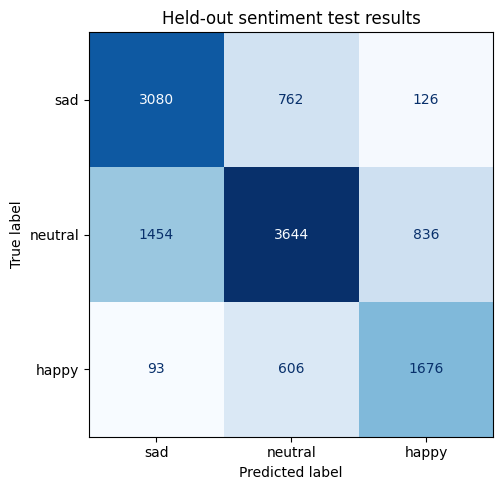

,text,label,predicted,actual
0,@user @user what do these '1/2 naked pics' hav...,1,sad,neutral
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",0,neutral,sad
5,Savchenko now Saakashvili took drug test live ...,1,sad,neutral
8,All CSG and Fracking all around Australia is t...,1,sad,neutral
9,@user @user @user @user @user @user take away ...,0,neutral,sad
13,"When Ryan privatizes SS, Medicare, Medicaid, &...",0,neutral,sad
14,Swampbitch Nasty Pelosi loves yelling 'Fire' i...,0,happy,sad
16,OPINION: The Anti-#Trump #Riots Are a #SmokeSc...,1,sad,neutral
17,ISIS and The CIA What You Need To Know! #ISIS ...,1,sad,neutral
18,@user alt-right was adopted by Deplorables. Av...,1,sad,neutral


In [20]:
test_metrics, test_truth, test_probabilities = evaluate_emotion(
    best_model,make_loader(splits['test'],tokenizer,BATCH_SIZE,MAX_LENGTH),DEVICE)
test_predictions=test_probabilities.argmax(axis=1)
test_scores=test_probabilities.max(axis=1)
accepted=test_scores>=review_threshold
test_metrics.update({'test_examples':len(test_truth),'accepted_examples':int(accepted.sum()),
                     'coverage':float(accepted.mean()),
                     'accepted_accuracy':float(accuracy_score(test_truth[accepted],test_predictions[accepted])) if accepted.any() else None})
print(json.dumps(test_metrics,indent=2))
(REPORTS/'test_metrics.json').write_text(json.dumps(test_metrics,indent=2))
per_class=pd.DataFrame(classification_report(test_truth,test_predictions,labels=[0,1,2],target_names=['sad','neutral','happy'],output_dict=True,zero_division=0)).T
per_class.to_csv(REPORTS/'classification_report.csv')
display(per_class)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
fig,ax=plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(test_truth,test_predictions,labels=[0,1,2]),display_labels=['sad','neutral','happy']).plot(ax=ax,cmap='Blues',colorbar=False)
ax.set_title('Held-out sentiment test results')
fig.tight_layout()
fig.savefig(REPORTS/'confusion_matrix.png',dpi=150)
plt.show()
errors=splits['test'].loc[test_truth!=test_predictions].copy()
errors['predicted']=[ID2LABEL[i] for i in test_predictions[test_truth!=test_predictions]]
errors['actual']=[ID2LABEL[i] for i in errors.label]
errors.to_csv(REPORTS/'test_errors.csv',index=False)
display(errors.head(12))


## Customer-support examples — qualitative checks only

These examples were written for demonstration. They are not an independent labeled benchmark and are not used in training or checkpoint selection. Inspect the outputs, including negation and sarcasm. A proper support evaluation should use independently reviewed messages with held-out labels.

The model expects **English**. Later, non-English customer messages must be translated before this module. Language detection by itself does not make an English sentiment classifier multilingual.


In [21]:
examples=[
 'I love the product. Thank you for the excellent service!',
 'My replacement arrived and I am really happy with it.',
 'Where can I download my invoice?',
 'Please update my delivery address.',
 'I want to return this item.',
 'I am so disappointed. My order arrived broken.',
 'This is unacceptable. I have been waiting for weeks!',
 'I am not happy with this service.',
 'Great, another late delivery. Just what I needed.',
 'The product is good, but the delivery was terrible.',
]
example_probabilities=predict_text_probabilities(best_model,tokenizer,examples,DEVICE,BATCH_SIZE,MAX_LENGTH)
example_results=pd.DataFrame({'text':examples,
    'predicted':[ID2LABEL[i] for i in example_probabilities.argmax(axis=1)],
    'confidence':example_probabilities.max(axis=1),
    'needs_review':example_probabilities.max(axis=1)<review_threshold})
display(example_results)
example_results.to_csv(REPORTS/'support_examples_qualitative.csv',index=False)


,text,predicted,confidence,needs_review
0,I love the product. Thank you for the excellen...,happy,0.990805,False
1,My replacement arrived and I am really happy w...,happy,0.991107,False
2,Where can I download my invoice?,neutral,0.918374,False
3,Please update my delivery address.,neutral,0.906184,False
4,I want to return this item.,neutral,0.730641,True
5,I am so disappointed. My order arrived broken.,sad,0.983786,False
6,This is unacceptable. I have been waiting for ...,sad,0.982740,False
7,I am not happy with this service.,sad,0.981849,False
8,"Great, another late delivery. Just what I needed.",happy,0.831267,True
9,"The product is good, but the delivery was terr...",sad,0.940994,False


## Export the model for VS Code

The export contains model weights in safetensors format, configuration with the exact label mapping, tokenizer files, metadata, checksums, and evaluation reports. This is more portable than saving a model object alone with pickle. Your local environment will still need compatible PyTorch and Transformers versions.

The reload check below confirms that saved weights produce the same predictions. Download the ZIP and the executed notebook. Do not submit a notebook with invented or empty training results as if training had finished.


In [22]:
import subprocess
import sys
def package_emotion_export(model_dir, report_dir, metadata, archive_base):
    """Bundle weights, tokenizer, configuration, metadata, reports, and checksums."""
    staging = Path(archive_base).parent / 'export_bundle'
    if staging.exists():
        shutil.rmtree(staging)
    shutil.copytree(model_dir, staging / 'model')
    (staging / 'model/metadata.json').write_text(json.dumps(metadata, indent=2) + '\n')
    shutil.copytree(report_dir, staging / 'reports')
    manifest = {}
    for path in sorted(staging.rglob('*')):
        if path.is_file():
            manifest[path.relative_to(staging).as_posix()] = hashlib.sha256(path.read_bytes()).hexdigest()
    (staging / 'manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')
    return Path(shutil.make_archive(str(archive_base), 'zip', staging))

metadata={'training_status':'full_training_completed','task':'three_class_customer_sentiment',
 'label_semantics':{'sad':'negative, including dissatisfaction and frustration','neutral':'neutral/factual','happy':'positive/satisfied'},
 'id2label':ID2LABEL,'model_id':MODEL_ID,'model_revision':MODEL_REVISION,'dataset':dataset_manifest,
 'max_length':MAX_LENGTH,'review_confidence_threshold':review_threshold,
 'seed':SEED,'epochs':EPOCHS,'batch_size':BATCH_SIZE,'learning_rate':LEARNING_RATE,
 'checkpoint_selection':selection,'validation_metrics':validation_metrics,'test_metrics':test_metrics,
 'class_counts':{split:{str(k):int(v) for k,v in frame.label.value_counts().items()} for split,frame in splits.items()},
 'split_audit':audit.to_dict(orient='records'),'completed_at_utc':datetime.now(timezone.utc).isoformat(),
 'versions':{package:version(package) for package in ['torch','transformers','tokenizers','numpy','pandas','pyarrow','scikit-learn','safetensors']},
 'limitations':['English only; translate other languages before classification.',
                'Sad is a negative-sentiment display name, not literal sadness.',
                'Twitter-to-customer-support domain shift.',
                'Sarcasm, mixed sentiment, short messages and ambiguous requests can be misclassified.',
                'Confidence values are uncalibrated; the review threshold is validation-derived.',
                'Exact duplicates removed; near duplicates may remain.']}
(REPORTS/'run_metadata.json').write_text(json.dumps(metadata,indent=2))
freeze=subprocess.check_output([sys.executable,'-m','pip','freeze'],text=True)
(REPORTS/'colab_requirements_snapshot.txt').write_text(freeze)
reloaded=AutoModelForSequenceClassification.from_pretrained(best_directory,use_safetensors=True).to(DEVICE)
reloaded.eval()
reload_probabilities=predict_text_probabilities(reloaded,tokenizer,examples[:3],DEVICE,3,MAX_LENGTH)
np.testing.assert_allclose(reload_probabilities,example_probabilities[:3],atol=1e-5)
print('Saved-model reload check passed.')
archive=package_emotion_export(best_directory,REPORTS,metadata,RUN/'emotion_classifier_export')
print('Export ready:',archive)
from google.colab import files
files.download(str(archive))


Saved-model reload check passed.
Export ready: /content/ITI_ChatBot_Emotion/runs/20260903-085248-280894/gentler_weights_20260903-085446-619413/emotion_classifier_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## What to send back and what to understand

Send **emotion_classifier_export.zip** and this notebook after downloading it with outputs from Colab. The local project contains an importer and prediction module ready for the export; no trained emotion model exists locally until then.

Be ready to explain:

1. Why we chose real neutral examples rather than map surprise to neutral.
2. Why “sad” here means negative sentiment, including frustration.
3. The difference between tokenization, pretraining, and fine-tuning.
4. Why class weights use only training counts.
5. Why the best checkpoint is chosen with validation macro-F1.
6. Why a language-detection score near 99% is not an expected sentiment score.
7. Why low confidence does not mean neutral.
8. Why the tokenizer must be exported with the model.
9. Why a Twitter test score does not prove customer-support accuracy.

If Colab runs out of GPU memory, restart with BATCH_SIZE=16 in a new run. If no GPU is available, wait for one or use another available Colab GPU runtime; do not accidentally start a long full run on the laptop CPU.
